#### Find the optimal depth (number of hidden layers) and width(number of neurons in each hidden layer) for the neural network designed in Question 1 and 2.

##### Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. You may consider different number of neurons for each hidden layer within an architecture. Continue using 5-fold cross validation on the training dataset. 

##### Identify the architecture with the highest validation accuracy among all tested combinations. 

##### Explain the possible reasons why it performed better than the other architectures. 

##### In general, discuss whether accuracy alone is sufficient when selecting the best model. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.

##### [optional + 2 marks] Implement an alternative approach that searches through these combinations that could significantly reduce the computational time but achieve similar search results, without enumeration all the possibilities.




This might take a while to run, so plan your time carefully.

#### 1. Firstly, we import relevant libraries.

In [1]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed
from common_utils import split_dataset, preprocess_dataset
from common_utils import MLP, loss_fn, CustomDataset, EarlyStopper
from common_utils import train_loop, test_loop

#### 2. To reduce repeated code, place your

- network (MLP defined in QA1)
- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)

in a separate file called **common_utils.py**

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [4]:
no_labels = 1
no_features = 77
no_hidden = 128

dropout_rate = 0.3

no_of_epochs = 200

learning_rate = 0.001
weight_decay = 0.0005
early_stopping_patience = 5
batch_size = 64

seed = 42
no_of_folds = 5

depth_of_layer = [1, 2, 3]
no_of_neuron = [64, 128, 256]

set_seed(seed)

In [6]:
def preprocess(df):
    x_train, y_train, x_test, y_test = split_dataset(df = df, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)
    
    return x_train, y_train, x_test, y_test

df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = preprocess(df)

#### 3. Perform hyperparameter tuning for different number of  hidden layers and neurons with 5-fold cross validation.

In [9]:
def train(model, X_train_scaled, y_train2, X_val_scaled, y_val2, learning_rate):

    train_data = CustomDataset(X_train_scaled, y_train2)
    val_data = CustomDataset(X_val_scaled, y_val2)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    early_stopper = EarlyStopper(patience=early_stopping_patience, min_delta=0)

    train_accuracies, train_losses = [], []
    test_accuracies, test_losses = [], []
    times = []

    epoch_count = 0
    for y in range(no_of_epochs):
        epoch_count += 1
        tr_loss, tr_acc = train_loop(train_loader, model, loss_fn, optimizer)
        test_loss, test_acc = test_loop(val_loader, model, loss_fn)

        train_accuracies.append(tr_acc)
        test_accuracies.append(test_acc)
        train_losses.append(tr_loss)
        test_losses.append(test_loss)
        times.append(epoch_count)

        if early_stopper.early_stop(test_loss):
            break
    

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [10]:
def find_optimal_hyperparameter(X_train, y_train, parameters, mode, learning_rate):
    kf = KFold(n_splits=no_of_folds, shuffle=True, random_state=seed)

    cross_validation_accuracies = {}
    cross_validation_times      = {}

    for arch in parameters:
        fold_val_accuracies = []
        fold_epochs         = []
        print(f"-----------------------------------------------------------------------------------------------")
        print(f"Current Architecture is {len(arch)} layers which is {arch}\n")

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            # ── Fold split + scale ─────────────────────────
            X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            X_fold_train_scaled, X_fold_val_scaled = preprocess_dataset(X_fold_train, X_fold_val)

            # ── Model ──────────────────────────────────────
            set_seed(seed)
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model = MLP(no_features=no_features, hidden_layers=arch, no_labels=no_labels, dropout_rate=dropout_rate).to(device)

            #── Train ──────────────────────────────────────
            _, _, test_accs, _, times = train(model, X_fold_train_scaled, y_fold_train,
                                                     X_fold_val_scaled,   y_fold_val,
                                                     learning_rate)

            fold_val_accuracies.append(test_accs[-1])
            fold_epochs.append(times[-1])
            print(f"  [{mode}={arch}] Fold {fold+1} | Val Acc: {test_accs[-1]:.4f} | Epochs: {times[-1]}")

        avg_acc    = sum(fold_val_accuracies) / len(fold_val_accuracies)
        avg_epochs = sum(fold_epochs)         / len(fold_epochs)

        arch_key = str(arch)
        cross_validation_accuracies[arch_key] = avg_acc
        cross_validation_times[arch_key]      = avg_epochs
        print(f"\n[{mode}={arch}] Avg Val Acc: {avg_acc:.4f} | Avg Epochs: {avg_epochs:.1f}")
        print(f"-----------------------------------------------------------------------------------------------")

    return cross_validation_accuracies, cross_validation_times

In [11]:
optimal_lr = learning_rate
parameters = [
    # 1 layer (3 combinations)
    [64],
    [128],
    [256],

    # 2 layers (9 combinations)
    [64,  64],
    [64,  128],
    [64,  256],
    [128, 64],
    [128, 128],
    [128, 256],
    [256, 64],
    [256, 128],
    [256, 256],

    # 3 layers (27 combinations)
    [64,  64,  64],
    [64,  64,  128],
    [64,  64,  256],
    [64,  128, 64],
    [64,  128, 128],
    [64,  128, 256],
    [64,  256, 64],
    [64,  256, 128],
    [64,  256, 256],
    [128, 64,  64],
    [128, 64,  128],
    [128, 64,  256],
    [128, 128, 64],
    [128, 128, 128],
    [128, 128, 256],
    [128, 256, 64],
    [128, 256, 128],
    [128, 256, 256],
    [256, 64,  64],
    [256, 64,  128],
    [256, 64,  256],
    [256, 128, 64],
    [256, 128, 128],
    [256, 128, 256],
    [256, 256, 64],
    [256, 256, 128],
    [256, 256, 256]
]

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train.to_numpy(), y_train, parameters, 'architecture', optimal_lr)

-----------------------------------------------------------------------------------------------
Current Architecture is 1 layers which is [64]

  [architecture=[64]] Fold 1 | Val Acc: 0.6412 | Epochs: 18
  [architecture=[64]] Fold 2 | Val Acc: 0.6313 | Epochs: 27
  [architecture=[64]] Fold 3 | Val Acc: 0.6615 | Epochs: 33
  [architecture=[64]] Fold 4 | Val Acc: 0.6582 | Epochs: 25
  [architecture=[64]] Fold 5 | Val Acc: 0.6350 | Epochs: 21

[architecture=[64]] Avg Val Acc: 0.6454 | Avg Epochs: 24.8
-----------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------
Current Architecture is 1 layers which is [128]

  [architecture=[128]] Fold 1 | Val Acc: 0.6722 | Epochs: 29
  [architecture=[128]] Fold 2 | Val Acc: 0.6534 | Epochs: 26
  [architecture=[128]] Fold 3 | Val Acc: 0.6554 | Epochs: 20
  [architecture=[128]] Fold 4 | Val Acc: 0.6731 | Epochs: 41
  [architec

#### 4. Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. 

In [19]:
# Sort by accuracy and take top 8
sorted_archs = sorted(cross_validation_accuracies.items(), key=lambda x: x[1], reverse=True)
top8_archs   = sorted_archs[:8]

top8_labels  = [item[0] for item in top8_archs]
top8_accs    = [item[1] for item in top8_archs]
x_pos        = range(len(top8_labels))

df_top8 = pd.DataFrame({
    'Rank'         : range(1, 9),
    'Architecture' : top8_labels,
    'CV Accuracy'  : [round(a, 4) for a in top8_accs],
    'Avg Epochs'   : [round(cross_validation_times[a], 1) for a in top8_labels]
})

df_top8

,Rank,Architecture,CV Accuracy,Avg Epochs
0,1,"[256, 128, 256]",0.7038,29.0
1,2,"[256, 256, 64]",0.6990,23.6
2,3,"[256, 128]",0.6990,23.4
3,4,"[256, 256, 256]",0.6980,22.6
4,5,"[256, 64]",0.6929,25.8
5,6,"[128, 256]",0.6923,28.6
6,7,"[256, 64, 64]",0.6904,23.6
7,8,"[128, 256, 128]",0.6885,24.0


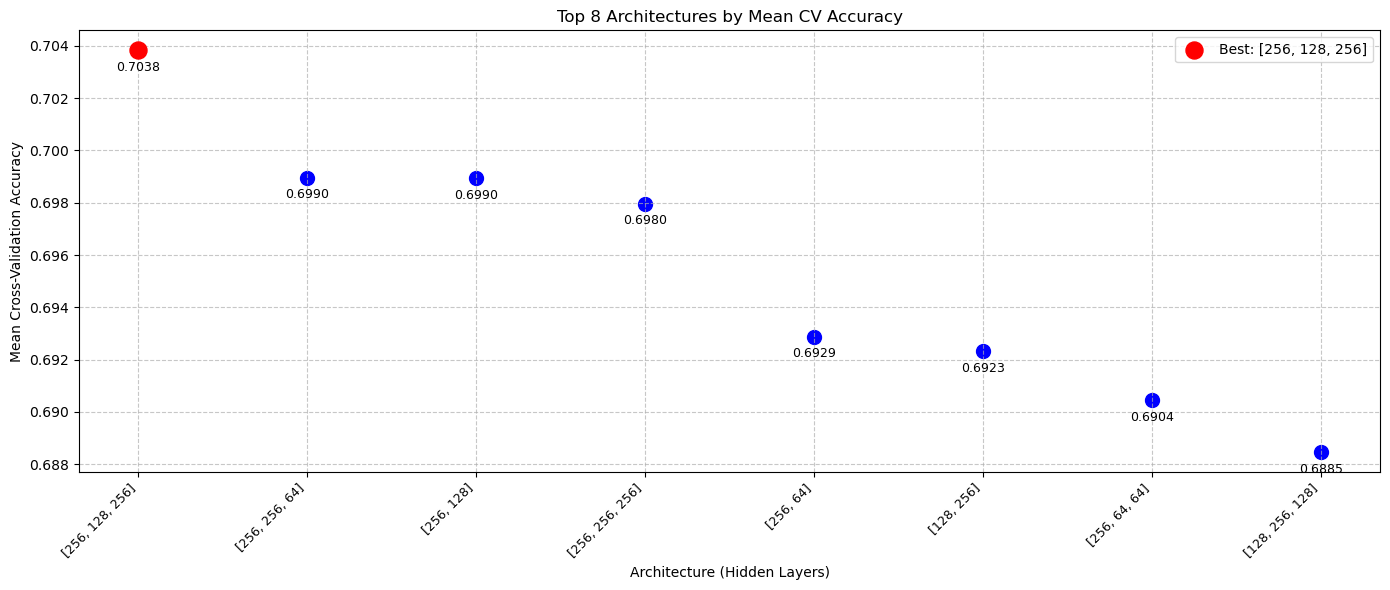

In [21]:
plt.figure(figsize=(14, 6))
plt.scatter(x_pos, top8_accs, color='blue', s=100)

# highlight best in red
plt.scatter(0, top8_accs[0], color='red', s=150, zorder=5, label=f'Best: {top8_labels[0]}')

# annotate below each dot
for i in range(len(top8_labels)):
    plt.annotate(f'{top8_accs[i]:.4f}', (x_pos[i], top8_accs[i]),
                 textcoords="offset points",
                 xytext=(0, -15),
                 ha='center',
                 fontsize=9)

plt.xticks(x_pos, top8_labels, rotation=45, ha='right', fontsize=9)
plt.xlabel('Architecture (Hidden Layers)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('Top 8 Architectures by Mean CV Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#### 5. Select the optimal combination for the depth and width. State the rationale for your selection.

In [11]:
optimal_combination = [256, 128, 256]

reason = f'''The optimal architecture selected is [256, 128, 256] with 3 hidden layers of 256, 128, and 256 neurons respectively.

It achieves the highest cross-validation accuracy of 0.7038 among all 39 tested combinations, outperforming the second best architecture [256, 256, 64] which achieved 0.6990.

Although architectures such as [256, 256, 64] and [256, 128] converge faster with fewer epochs (23.6 and 23.4 respectively) compared to [256, 128, 256] (29.0 epochs), the improvement in validation accuracy justifies the additional computational cost.

The architecture follows a wide-narrow-wide pattern (256→128→256), which allows the network to first extract a broad set of features, compress them into a lower-dimensional representation in the middle layer, and then re-expand to capture more complex feature interactions before the output. This bottleneck-like structure helps the model generalize better compared to monotonically decreasing or uniform architectures.

Simpler architectures such as [256, 64] and [128, 256] with fewer layers achieved lower accuracies of 0.6929 and 0.6923 respectively, suggesting that additional depth is beneficial for this dataset.

Therefore, [256, 128, 256] strikes the best balance between accuracy and model complexity.'''

print(reason)

The optimal architecture selected is [256, 128, 256] with 3 hidden layers of 256, 128, and 256 neurons respectively.

It achieves the highest cross-validation accuracy of 0.7038 among all 39 tested combinations, outperforming the second best architecture [256, 256, 64] which achieved 0.6990.

Although architectures such as [256, 256, 64] and [256, 128] converge faster with fewer epochs (23.6 and 23.4 respectively) compared to [256, 128, 256] (29.0 epochs), the improvement in validation accuracy justifies the additional computational cost.

The architecture follows a wide-narrow-wide pattern (256→128→256), which allows the network to first extract a broad set of features, compress them into a lower-dimensional representation in the middle layer, and then re-expand to capture more complex feature interactions before the output. This bottleneck-like structure helps the model generalize better compared to monotonically decreasing or uniform architectures.

Simpler architectures such as [25

#### 6. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.


In [48]:
# Train final model with optimal architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(seed)
optimal_model = MLP(no_features=no_features, hidden_layers=optimal_combination,
                    no_labels=no_labels, dropout_rate=dropout_rate).to(device)

# Scale full train and test data
X_train_scaled, X_test_scaled = preprocess_dataset(X_train.to_numpy(), X_test.to_numpy())

# Use train() function directly
tr_acc, tr_loss, te_acc, te_loss, times = train(
    optimal_model, X_train_scaled, y_train,
    X_test_scaled,  y_test,
    learning_rate
)

#Save the model
torch.save(optimal_model, 'optimal_model_full.pth')
print("Model saved!")

# Print results
for i in range(len(times)):
    print(f"Epoch {times[i]:3d} | Train Acc: {tr_acc[i]:.4f} | Train Loss: {tr_loss[i]:.6f} | Test Acc: {te_acc[i]:.4f} | Test Loss: {te_loss[i]:.6f}")

print(f"\nFinal Train Accuracy : {tr_acc[-1]:.4f}")
print(f"Final Test Accuracy  : {te_acc[-1]:.4f}")

Model saved!
Epoch   1 | Train Acc: 0.5486 | Train Loss: 0.010768 | Test Acc: 0.5675 | Test Loss: 0.010833
Epoch   2 | Train Acc: 0.5999 | Train Loss: 0.010450 | Test Acc: 0.6076 | Test Loss: 0.010628
Epoch   3 | Train Acc: 0.6191 | Train Loss: 0.010218 | Test Acc: 0.6252 | Test Loss: 0.010304
Epoch   4 | Train Acc: 0.6263 | Train Loss: 0.010051 | Test Acc: 0.6401 | Test Loss: 0.010134
Epoch   5 | Train Acc: 0.6490 | Train Loss: 0.009761 | Test Acc: 0.6431 | Test Loss: 0.010092
Epoch   6 | Train Acc: 0.6584 | Train Loss: 0.009615 | Test Acc: 0.6451 | Test Loss: 0.009996
Epoch   7 | Train Acc: 0.6783 | Train Loss: 0.009359 | Test Acc: 0.6444 | Test Loss: 0.009968
Epoch   8 | Train Acc: 0.6894 | Train Loss: 0.009139 | Test Acc: 0.6375 | Test Loss: 0.010154
Epoch   9 | Train Acc: 0.7035 | Train Loss: 0.008832 | Test Acc: 0.6753 | Test Loss: 0.009452
Epoch  10 | Train Acc: 0.7119 | Train Loss: 0.008690 | Test Acc: 0.6806 | Test Loss: 0.009617
Epoch  11 | Train Acc: 0.7273 | Train Loss: 0.0


Final Train Accuracy : 0.7457
Final Test Accuracy  : 0.6869
Best  Test Accuracy  : 0.6869 at Epoch 14


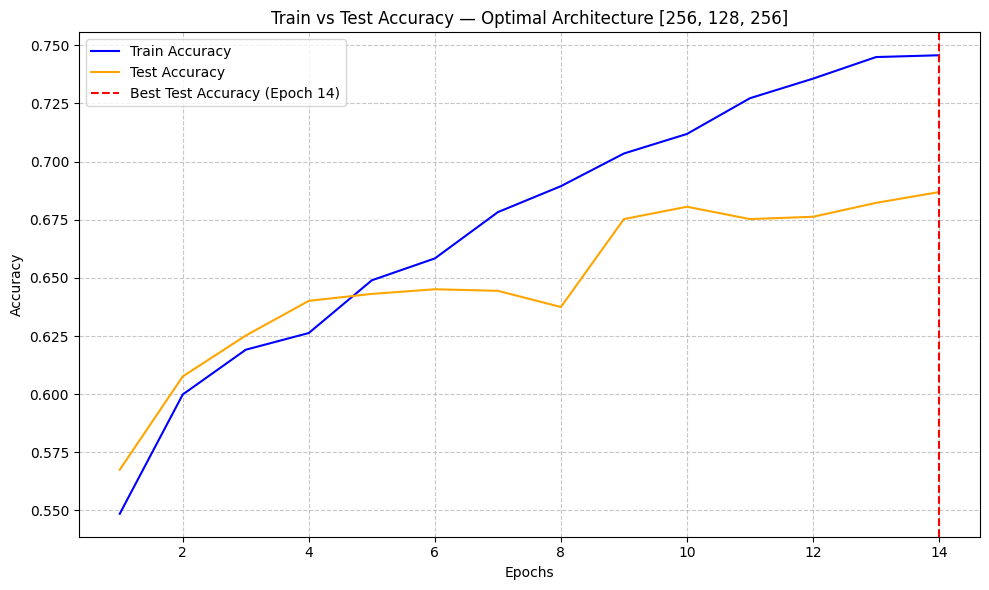

In [50]:
#Plot
epochs = range(1, len(tr_acc)+1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, te_acc, label='Test Accuracy',  color='orange')

# mark best test accuracy
best_epoch = te_acc.index(max(te_acc)) + 1

print(f"\nFinal Train Accuracy : {tr_acc[-1]:.4f}")
print(f"Final Test Accuracy  : {te_acc[-1]:.4f}")
print(f"Best  Test Accuracy  : {max(te_acc):.4f} at Epoch {best_epoch}")

plt.axvline(best_epoch, linestyle='--', color='red', label=f'Best Test Accuracy (Epoch {best_epoch})')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy — Optimal Architecture {optimal_combination}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 7. As you've astutely observed, we're facing a significant challenge in enumerating all possible combinations of widths and depths and searching over them. Given the circumstances, could you explore and implement a more efficient method for searching through these combinations that could significantly reduce the computational time but achieve similar search results?

#### **<u>Greedy Layer-wise Architecture Search Approach<u>**
Since searching over all possible combinations of depth and width in a neural network is computationally expensive, I will adopt a **Greedy Layer-wise Architecture Search Approach (GLNAS)**. According to the work of Bengio et al. (2007) on GLNAS, the core idea is to train and evaluate one hidden layer at a time and select the best width for each layer before proceeding to the next. This method will significatly decrease our search combinations from 39 to 9 and recude the computational cost.

> *References: GLNAS: Greedy Layer-wise Network Architecture Search for low cost and fast network generation. Pattern Recognition, 2024. [https://www.sciencedirect.com/article/pii/S0031320324004813]*

In [40]:
def greedy_architecture_search(X_train, y_train, learning_rate):
    widths           = [64, 128, 256]
    best_arch        = []
    all_scores       = {}
    best_overall_acc = 0

    for layer in range(1, 4):
        print(f"\n{'='*60}")
        print(f"LAYER {layer} SEARCH")
        print(f"{'='*60}")
        
        layer_scores = {}

        for width in widths:
            candidate           = best_arch + [width]
            kf                  = KFold(n_splits=no_of_folds, shuffle=True, random_state=seed)
            fold_val_accuracies = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
                X_fold_train_scaled, X_fold_val_scaled = preprocess_dataset(X_fold_train, X_fold_val)

                set_seed(seed)
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                model  = MLP(no_features=no_features, hidden_layers=candidate,
                             no_labels=no_labels, dropout_rate=dropout_rate).to(device)

                train_accs, train_losses, test_accs, test_losses, times = train(
                    model, X_fold_train_scaled, y_fold_train,
                    X_fold_val_scaled, y_fold_val, learning_rate
                )

                fold_val_accuracies.append(test_accs[-1])
                print(f"  [arch={candidate}] Fold {fold+1} | Train Acc: {train_accs[-1]:.4f} | Train Loss: {train_losses[-1]:.6f} | Val Acc: {test_accs[-1]:.4f} | Val Loss: {test_losses[-1]:.6f} | Epochs: {times[-1]}")

            avg_acc                    = sum(fold_val_accuracies) / len(fold_val_accuracies)
            layer_scores[width]        = avg_acc
            all_scores[str(candidate)] = avg_acc
            print(f"  [arch={candidate}] Avg Val Accuracy: {avg_acc:.4f}\n")

        # check if adding this layer improves accuracy
        best_width     = max(layer_scores, key=layer_scores.get)
        best_layer_acc = layer_scores[best_width]

        if best_layer_acc > best_overall_acc:
            best_overall_acc = best_layer_acc
            best_arch.append(best_width)
            print(f"Layer {layer} added | Best arch so far: {best_arch} | Acc: {best_overall_acc:.4f}\n")
        else:
            print(f"Layer {layer} stopped | No improvement over {best_overall_acc:.4f}")
            print(f"Final architecture: {best_arch}")
            break

    return best_arch, all_scores

In [42]:
# ── Run greedy search ──────────────────────────────────────────────
greedy_best_arch, greedy_scores = greedy_architecture_search(
    X_train.to_numpy(), y_train, learning_rate
)

print(f"\n{'='*50}")
print(f"Greedy Best Architecture : {greedy_best_arch}")
print(f"{'='*50}")


LAYER 1 SEARCH
  [arch=[64]] Fold 1 | Train Acc: 0.6732 | Train Loss: 0.009495 | Val Acc: 0.6412 | Val Loss: 0.010208 | Epochs: 18
  [arch=[64]] Fold 2 | Train Acc: 0.6998 | Train Loss: 0.009100 | Val Acc: 0.6313 | Val Loss: 0.010263 | Epochs: 27
  [arch=[64]] Fold 3 | Train Acc: 0.7159 | Train Loss: 0.008752 | Val Acc: 0.6615 | Val Loss: 0.009952 | Epochs: 33
  [arch=[64]] Fold 4 | Train Acc: 0.7087 | Train Loss: 0.009085 | Val Acc: 0.6582 | Val Loss: 0.010013 | Epochs: 25
  [arch=[64]] Fold 5 | Train Acc: 0.6843 | Train Loss: 0.009417 | Val Acc: 0.6350 | Val Loss: 0.010262 | Epochs: 21
  [arch=[64]] Avg Val Accuracy: 0.6454

  [arch=[128]] Fold 1 | Train Acc: 0.7285 | Train Loss: 0.008517 | Val Acc: 0.6722 | Val Loss: 0.009811 | Epochs: 29
  [arch=[128]] Fold 2 | Train Acc: 0.7296 | Train Loss: 0.008772 | Val Acc: 0.6534 | Val Loss: 0.010001 | Epochs: 26
  [arch=[128]] Fold 3 | Train Acc: 0.7103 | Train Loss: 0.008854 | Val Acc: 0.6554 | Val Loss: 0.010067 | Epochs: 20
  [arch=[128]

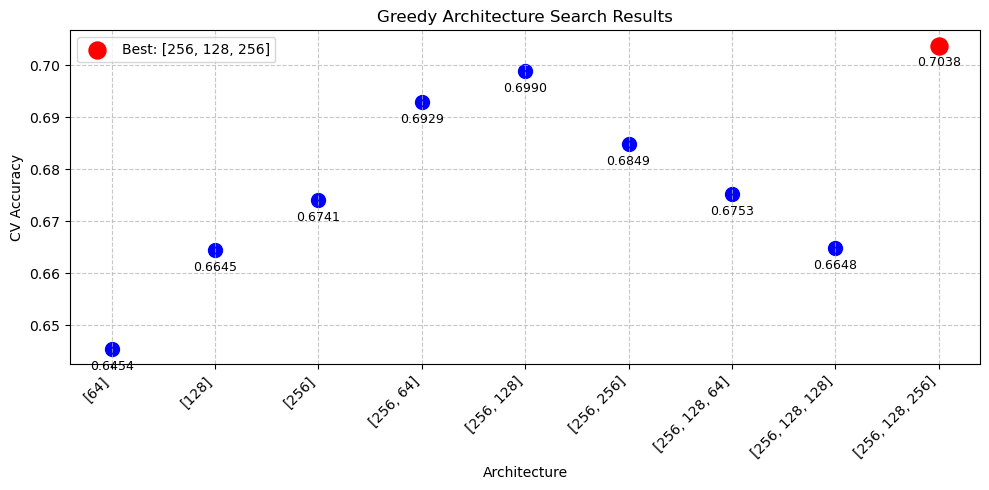

In [98]:
#plot the greedy search results
arch_labels = list(greedy_scores.keys())
accs        = list(greedy_scores.values())
x_pos       = range(len(arch_labels))

plt.figure(figsize=(10, 5))
plt.scatter(x_pos, accs, color='blue', s=100)

best_idx = accs.index(max(accs))
plt.scatter(x_pos[best_idx], accs[best_idx], color='red', s=150, 
            zorder=5, label=f'Best: {arch_labels[best_idx]}')

for i in range(len(arch_labels)):
    plt.annotate(f'{accs[i]:.4f}', (x_pos[i], accs[i]),
                 textcoords="offset points",
                 xytext=(0, -15), ha='center', fontsize=9)

plt.xticks(x_pos, arch_labels, rotation=45, ha='right')
plt.xlabel('Architecture')
plt.ylabel('CV Accuracy')
plt.title('Greedy Architecture Search Results')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#### Limitation and Drawbacks
Using this approach, I get the same result as the full search through the whole 
combination with a lower computational cost (9 evaluations). However, its key 
drawback is that it makes locally optimal decisions at each layer without 
considering the global combinations. This means architectures where a suboptimal 
early layer leads to better overall combination, such as [64, 128] and [256, 128], 
are completely missed. Despite the limitation, greedy search remains a practical 
trade-off between search efficiency and optimality when computational resources 
are limited.

#### <u>Successive Halving Algorithm<u>
An alternative way other than GLNAS is using the Successive Halving Algorithm. 
It is the fundamental idea of the Hyperband search algorithm. It begins by 
training all architectures for a small number of epochs, progressively eliminating 
the worst-performing configurations while allocating more epochs to the surviving 
ones. This allows the algorithm to explore a much wider range of architectures 
than greedy search while being faster than a full iteration of all combinations.

> Jamieson, K., & Talwalkar, A. (2016). Non-stochastic Best Arm Identification 
> and Hyperparameter Optimization. *Proceedings of AISTATS 2016*.
]

In [117]:
def hyperband_architecture_search(X_train, y_train, learning_rate):
    all_architectures = [
        [64], [128], [256],
        [64, 64], [64, 128], [64, 256],
        [128, 64], [128, 128], [128, 256],
        [256, 64], [256, 128], [256, 256],
        [64, 64, 64], [64, 64, 128], [64, 64, 256],
        [64, 128, 64], [64, 128, 128], [64, 128, 256],
        [64, 256, 64], [64, 256, 128], [64, 256, 256],
        [128, 64, 64], [128, 64, 128], [128, 64, 256],
        [128, 128, 64], [128, 128, 128], [128, 128, 256],
        [128, 256, 64], [128, 256, 128], [128, 256, 256],
        [256, 64, 64], [256, 64, 128], [256, 64, 256],
        [256, 128, 64], [256, 128, 128], [256, 128, 256],
        [256, 256, 64], [256, 256, 128], [256, 256, 256],
    ]

    candidates  = all_architectures.copy()
    all_scores  = {}
    round_num   = 1

    global no_of_epochs   # temporarily override epochs each round
    original_epochs = no_of_epochs
    no_of_epochs    = 5   # start with 5 epochs

    while len(candidates) > 1:
        print(f"\n[Round {round_num}] Candidates: {len(candidates)} | Epochs: {no_of_epochs}")
        print(f"{'-'*60}")

        round_scores = {}

        for arch in candidates:
            kf = KFold(n_splits=no_of_folds, shuffle=True, random_state=seed)
            fold_val_accuracies = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                # Fold split + scale
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
                X_fold_train_scaled, X_fold_val_scaled = preprocess_dataset(X_fold_train, X_fold_val)

                # Model
                set_seed(seed)
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                model  = MLP(no_features=no_features, hidden_layers=arch,
                             no_labels=no_labels, dropout_rate=dropout_rate).to(device)

                # Use train() function
                _, _, test_accs, test_losses, times = train(
                    model, X_fold_train_scaled, y_fold_train,
                    X_fold_val_scaled, y_fold_val, learning_rate
                )

                fold_val_accuracies.append(test_accs[-1])
                print(f"  [arch={arch}] Fold {fold+1} | Val Acc: {test_accs[-1]:.4f} | Train Acc: {_[- 1]:.4f} | Epochs: {times[-1]}")

            avg_acc                 = sum(fold_val_accuracies) / len(fold_val_accuracies)
            round_scores[str(arch)] = avg_acc
            all_scores[str(arch)]   = avg_acc
            print(f"  [arch={arch}] Avg Val Accuracy: {avg_acc:.4f}\n")

        # Eliminate the worst half
        sorted_archs = sorted(round_scores, key=round_scores.get, reverse=True)
        keep         = max(1, len(sorted_archs) // 2)
        candidates   = [eval(a) for a in sorted_archs[:keep]]
        no_of_epochs += 5   # increase by 5 each round

        print(f"[Round {round_num}] Kept top {keep}: {candidates}")
        round_num += 1

    # restore original epochs
    no_of_epochs = original_epochs

    best_arch = candidates[0]
    print(f"\nHyperband Best Architecture : {best_arch}")
    print(f"Best CV Accuracy            : {all_scores[str(best_arch)]:.4f}")

    return best_arch, all_scores

In [119]:
hyperband_best_arch, hyperband_scores = hyperband_architecture_search(
    X_train.to_numpy(), y_train, optimal_lr
)


[Round 1] Candidates: 39 | Epochs: 5
------------------------------------------------------------
  [arch=[64]] Fold 1 | Val Acc: 0.6059 | Train Acc: 0.0103 | Epochs: 5
  [arch=[64]] Fold 2 | Val Acc: 0.6036 | Train Acc: 0.0102 | Epochs: 5
  [arch=[64]] Fold 3 | Val Acc: 0.6018 | Train Acc: 0.0103 | Epochs: 5
  [arch=[64]] Fold 4 | Val Acc: 0.6090 | Train Acc: 0.0102 | Epochs: 5
  [arch=[64]] Fold 5 | Val Acc: 0.5929 | Train Acc: 0.0102 | Epochs: 5
  [arch=[64]] Avg Val Accuracy: 0.6026

  [arch=[128]] Fold 1 | Val Acc: 0.6064 | Train Acc: 0.0101 | Epochs: 5
  [arch=[128]] Fold 2 | Val Acc: 0.5954 | Train Acc: 0.0101 | Epochs: 5
  [arch=[128]] Fold 3 | Val Acc: 0.6150 | Train Acc: 0.0101 | Epochs: 5
  [arch=[128]] Fold 4 | Val Acc: 0.6233 | Train Acc: 0.0102 | Epochs: 5
  [arch=[128]] Fold 5 | Val Acc: 0.6178 | Train Acc: 0.0101 | Epochs: 5
  [arch=[128]] Avg Val Accuracy: 0.6116

  [arch=[256]] Fold 1 | Val Acc: 0.6164 | Train Acc: 0.0100 | Epochs: 5
  [arch=[256]] Fold 2 | Val Acc: 

In [147]:
#Top 10 Summary Table
sorted_scores = sorted(hyperband_scores.items(), key=lambda x: x[1], reverse=True)
arch_labels   = [item[0] for item in sorted_scores]

df_hyperband = pd.DataFrame({
    'Rank'         : range(1, 11),
    'Architecture' : arch_labels[:10]
})
df_hyperband

,Rank,Architecture
0,1,"[256, 256, 256]"
1,2,"[256, 128]"
2,3,"[256, 256]"
3,4,"[256, 256, 128]"
4,5,"[256, 128, 256]"
5,6,"[128, 256, 256]"
6,7,"[256, 256, 64]"
7,8,"[256, 64, 64]"
8,9,"[256, 64, 256]"
9,10,"[256, 128, 128]"


#### Limitation and Drawbacks

The Successive Halving Algorithm identified [256, 256, 256] as the optimal 
architecture, which is the fourth-best result compared to full enumeration. 
Although it did not identify the globally optimal architecture, the difference 
in validation accuracy between the best and second-best architecture is 
acceptable, suggesting that both architectures perform comparably in practice.

This outcome highlights a fundamental trade-off in hyperparameter search, which is
reducing the search space inevitably risks missing the globally optimal solution. 
However, given the significant reduction in computational cost compared to full 
enumeration, obtaining a near-optimal architecture with minimal accuracy.
Sacrifice is an acceptable trade-off. 

Both experiments demonstrate that both methods are practical and efficient alternatives when exhaustive search is computationally infeasible.